# 🎙️ Module 8 — Deep Learning for Speech Emotion Recognition

**Project:** Speech Emotion Recognition System  
**Dataset:** RAVDESS — 1,440 clips, 264 features, 8 emotion classes  
**Goal:** Build, train and compare two deep learning architectures:
1. **ANN (Artificial Neural Network)** — dense layers on flat feature vector  
2. **CNN (Convolutional Neural Network)** — learns spatial patterns from MFCC 2-D maps  

---
### Pipeline
```
Flat Features (264) → StandardScaler → ANN → Softmax (8)
MFCC 2-D (40×130)  → CNN Layers     → ANN → Softmax (8)
```

## 8.1 — Imports & GPU Check

In [1]:
import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.utils import to_categorical

import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, f1_score,
                                      precision_score, recall_score,
                                      confusion_matrix, classification_report)
import sys
sys.path.insert(0, '..')
from src.feature_extraction import extract_mfcc_2d
import librosa

# ── Theme ──────────────────────────────────────────────────────────────────
DARK  = '#0d0d1a'; PANEL = '#12122a'; TEXT = '#e2e8f0'
plt.rcParams.update({
    'figure.facecolor': DARK,  'axes.facecolor': PANEL,
    'axes.labelcolor' : TEXT,  'text.color'    : TEXT,
    'xtick.color': '#9090b0',  'ytick.color'   : '#9090b0',
    'grid.color' : '#252545',  'font.size'     : 10,
})
sns.set_style('darkgrid')
ECOLORS = {
    'neutral':'#94a3b8','calm':'#22d3ee','happy':'#fbbf24','sad':'#60a5fa',
    'angry':'#f87171','fearful':'#c084fc','disgust':'#4ade80','surprised':'#fb923c'
}

# ── Paths ──────────────────────────────────────────────────────────────────
BASE      = os.path.dirname(os.path.abspath('__file__'))
DATA_PROC = os.path.join(BASE, '..', 'data', 'processed')
MODEL_DIR = os.path.join(BASE, '..', 'models')
REP_DIR   = os.path.join(BASE, '..', 'reports', 'evaluation')
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REP_DIR,   exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
VAL_SIZE     = 0.10

print(f'✅ TensorFlow version : {tf.__version__}')
print(f'   Keras version      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'   GPUs available     : {len(gpus)} ({gpus if gpus else "CPU only"})')

✅ TensorFlow version : 2.21.0
   Keras version      : 3.15.1


   GPUs available     : 0 (CPU only)


## 8.2 — Load Data

In [2]:
X_feat = np.load(os.path.join(DATA_PROC, 'X_features.npy'))  # (1440, 264)
X_audio= np.load(os.path.join(DATA_PROC, 'X_audio.npy'))     # (1440, 66150)
y_raw  = np.load(os.path.join(DATA_PROC, 'y_labels.npy'))    # (1440,)

with open(os.path.join(DATA_PROC, 'preprocessing_config.json')) as f:
    cfg = json.load(f)
EMOTIONS  = cfg['emotion_classes']
N_CLASSES = len(EMOTIONS)
SR        = cfg['target_sr']

print(f'✅ Data loaded')
print(f'   X_features shape : {X_feat.shape}')
print(f'   X_audio shape    : {X_audio.shape}')
print(f'   Labels shape     : {y_raw.shape}')
print(f'   Classes ({N_CLASSES}) : {EMOTIONS}')

✅ Data loaded
   X_features shape : (1440, 264)
   X_audio shape    : (1440, 66150)
   Labels shape     : (1440,)
   Classes (8) : ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']


## 8.3 — Prepare ANN Input (Flat Feature Vector)

In [3]:
# ── Stratified split: 80% train, 10% val, 10% test ────────────────────────
X_tr0, X_test, y_tr0, y_test = train_test_split(
    X_feat, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw)
X_train, X_val, y_train, y_val = train_test_split(
    X_tr0, y_tr0,
    test_size   = VAL_SIZE / (1 - TEST_SIZE),
    random_state= RANDOM_STATE,
    stratify    = y_tr0
)

# Scale features
scaler = joblib.load(os.path.join(MODEL_DIR, 'scaler.pkl'))
X_train_sc = scaler.transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# One-hot encode labels
y_train_oh  = to_categorical(y_train, N_CLASSES)
y_val_oh    = to_categorical(y_val,   N_CLASSES)
y_test_oh   = to_categorical(y_test,  N_CLASSES)

print('✂️  Dataset Splits')
print(f'   Train : {X_train_sc.shape}  ({len(X_train)} samples)')
print(f'   Val   : {X_val_sc.shape}    ({len(X_val)} samples)')
print(f'   Test  : {X_test_sc.shape}   ({len(X_test)} samples)')

✂️  Dataset Splits
   Train : (1008, 264)  (1008 samples)
   Val   : (144, 264)    (144 samples)
   Test  : (288, 264)   (288 samples)


## 8.4 — Prepare CNN Input (2-D MFCC Maps)

In [4]:
N_MFCC     = 40
MAX_FRAMES = 130

print(f'🔄 Building 2-D MFCC tensors  (shape: N × {N_MFCC} × {MAX_FRAMES} × 1) ...')
t0 = time.time()

X_mfcc_2d = np.stack([
    extract_mfcc_2d(sig, sr=SR, n_mfcc=N_MFCC, max_frames=MAX_FRAMES)
    for sig in X_audio
])  # (1440, 40, 130)

# Normalise each clip to zero mean / unit variance (clip-wise)
mean_ = X_mfcc_2d.mean(axis=(1,2), keepdims=True)
std_  = X_mfcc_2d.std(axis=(1,2),  keepdims=True) + 1e-8
X_mfcc_2d = (X_mfcc_2d - mean_) / std_

# Add channel dim → (1440, 40, 130, 1)
X_mfcc_2d = X_mfcc_2d[..., np.newaxis].astype(np.float32)

# Split (same indices as ANN)
X_cnn_tr0,  X_cnn_test, y_cnn_tr0,  _ = train_test_split(
    X_mfcc_2d, y_raw, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_raw)
X_cnn_train, X_cnn_val, y_cnn_train, y_cnn_val = train_test_split(
    X_cnn_tr0, y_cnn_tr0,
    test_size   = VAL_SIZE / (1 - TEST_SIZE),
    random_state= RANDOM_STATE,
    stratify    = y_cnn_tr0
)

y_cnn_train_oh = to_categorical(y_cnn_train, N_CLASSES)
y_cnn_val_oh   = to_categorical(y_cnn_val,   N_CLASSES)
y_cnn_test     = _  = y_test    # same test labels

print(f'   Done in {time.time()-t0:.1f}s')
print(f'   X_cnn_2d shape : {X_mfcc_2d.shape}  (clips × H × W × C)')
print(f'   Train : {X_cnn_train.shape}')
print(f'   Val   : {X_cnn_val.shape}')
print(f'   Test  : {X_cnn_test.shape}')

🔄 Building 2-D MFCC tensors  (shape: N × 40 × 130 × 1) ...


   Done in 15.8s
   X_cnn_2d shape : (1440, 40, 130, 1)  (clips × H × W × C)
   Train : (1008, 40, 130, 1)
   Val   : (144, 40, 130, 1)
   Test  : (288, 40, 130, 1)


## 8.5 — Build ANN Architecture

In [5]:
def build_ann(input_dim: int, n_classes: int) -> keras.Model:
    """
    Deep Feed-Forward ANN for speech emotion classification.
    
    Architecture:
      Input(264) → Dense(512) → BN → Dropout(0.4)
              → Dense(256) → BN → Dropout(0.35)
              → Dense(128) → BN → Dropout(0.30)
              → Dense(64)  → BN → Dropout(0.25)
              → Dense(8)   → Softmax
    """
    inp = keras.Input(shape=(input_dim,), name='feature_input')

    x = layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4), name='fc1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.Dropout(0.40, name='drop1')(x)

    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.Dropout(0.35, name='drop2')(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='fc3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.Dropout(0.30, name='drop3')(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name='fc4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.Activation('relu', name='relu4')(x)
    x = layers.Dropout(0.25, name='drop4')(x)

    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inp, out, name='SER_ANN')


ann_model = build_ann(X_train_sc.shape[1], N_CLASSES)
ann_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
ann_model.summary()
total_params = ann_model.count_params()
print(f'\n✅ ANN built  |  Total parameters: {total_params:,}')

Model: "SER_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feature_input (InputLayer)      │ (None, 264)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc4 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop4 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,520 (1.19 MB)

 Trainable params: 310,600 (1.18 MB)

 Non-trainable params: 1,920 (7.50 KB)


✅ ANN built  |  Total parameters: 312,520


## 8.6 — Train ANN

In [6]:
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Callbacks ──────────────────────────────────────────────────────────────
ann_ckpt = os.path.join(MODEL_DIR, 'ann_best.keras')
ann_callbacks = [
    callbacks.ModelCheckpoint(
        ann_ckpt, monitor='val_accuracy', save_best_only=True,
        verbose=1, mode='max'
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
]

print('🚀 Training ANN...')
t0 = time.time()
ann_history = ann_model.fit(
    X_train_sc, y_train_oh,
    validation_data = (X_val_sc, y_val_oh),
    epochs          = 150,
    batch_size      = 32,
    callbacks       = ann_callbacks,
    verbose         = 1
)
ann_train_time = time.time() - t0
print(f'\n✅ ANN training complete in {ann_train_time:.1f}s')

🚀 Training ANN...
Epoch 1/150


 1/32 ━━━━━━━━━━━━━━━━━━━━ 2:00 4s/step - accuracy: 0.0938 - loss: 2.7862

10/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1406 - loss: 2.5533 

21/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1443 - loss: 2.4790

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1518 - loss: 2.4325

...


Epoch 69: val_accuracy did not improve from 0.63889


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9345 - loss: 0.3503 - val_accuracy: 0.6181 - val_loss: 1.4572 - learning_rate: 6.2500e-05


Epoch 69: early stopping


Restoring model weights from the end of the best epoch: 49.



✅ ANN training complete in 27.9s


## 8.7 — ANN Training Curves

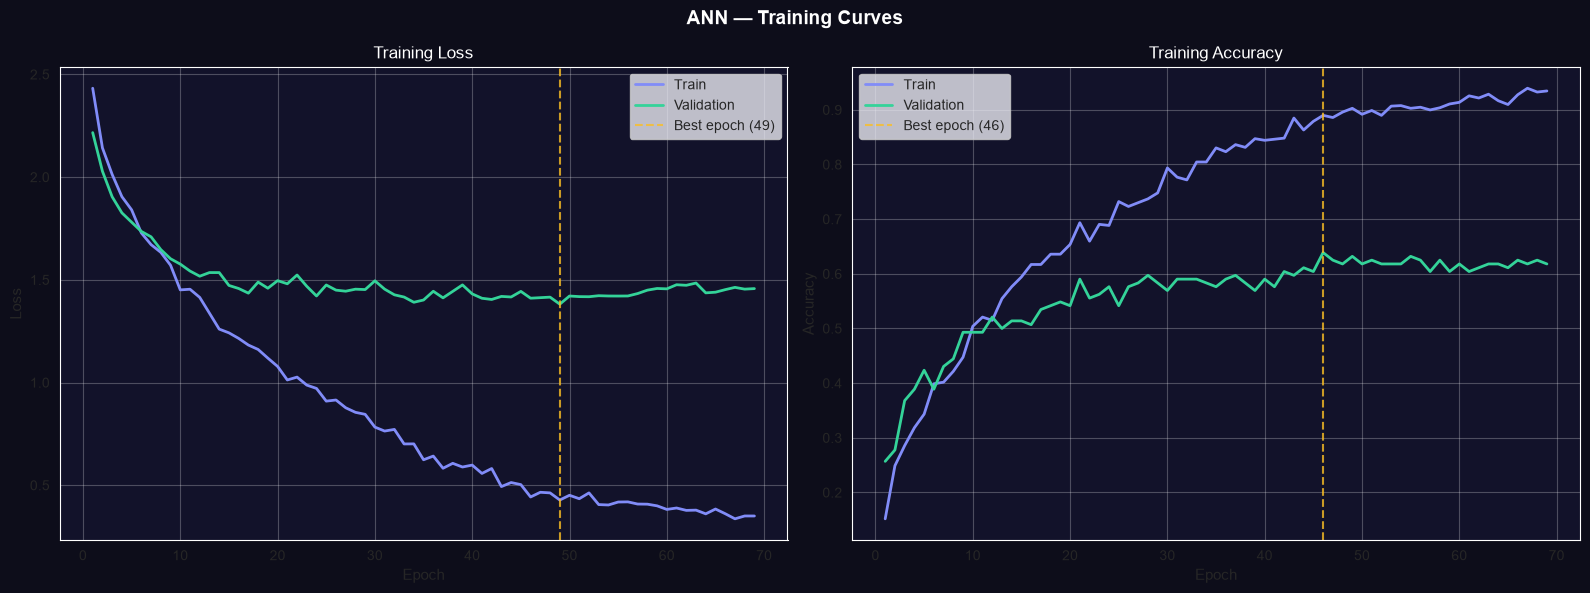

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\ann_training_curves.png


In [7]:
def plot_history(history, title, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.patch.set_facecolor(DARK)
    fig.suptitle(title, fontsize=14, fontweight='bold', color='white')

    ep = range(1, len(history.history['accuracy']) + 1)

    for ax, (metric, display) in zip(axes, [('loss','Loss'),('accuracy','Accuracy')]):
        ax.set_facecolor(PANEL)
        ax.plot(ep, history.history[metric],         color='#818cf8',
                linewidth=2, label='Train')
        ax.plot(ep, history.history[f'val_{metric}'],color='#34d399',
                linewidth=2, label='Validation')
        best_ep = (np.argmin(history.history['val_loss'])
                   if metric == 'loss'
                   else np.argmax(history.history['val_accuracy']))
        ax.axvline(best_ep + 1, color='#fbbf24', linestyle='--',
                   linewidth=1.5, alpha=0.8, label=f'Best epoch ({best_ep+1})')
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(display, fontsize=11)
        ax.set_title(f'Training {display}', color='white', fontsize=12)
        ax.legend(fontsize=10)
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()
    print(f'✅ Saved → {save_path}')


plot_history(ann_history, 'ANN — Training Curves',
             os.path.join(REP_DIR, 'ann_training_curves.png'))

## 8.8 — ANN Evaluation


───────────────────────────────────────────────────────
  📊  ANN  —  Test Results
───────────────────────────────────────────────────────
  Accuracy   : 62.85%
  Precision  : 66.51%
  Recall     : 62.85%
  F1-Score   : 62.90%

              precision    recall  f1-score   support

     neutral       0.34      0.68      0.46        19
        calm       0.68      0.71      0.69        38
       happy       0.82      0.37      0.51        38
         sad       0.66      0.61      0.63        38
       angry       0.75      0.69      0.72        39
     fearful       0.67      0.67      0.67        39
     disgust       0.66      0.55      0.60        38
   surprised       0.59      0.77      0.67        39

    accuracy                           0.63       288
   macro avg       0.64      0.63      0.62       288
weighted avg       0.67      0.63      0.63       288



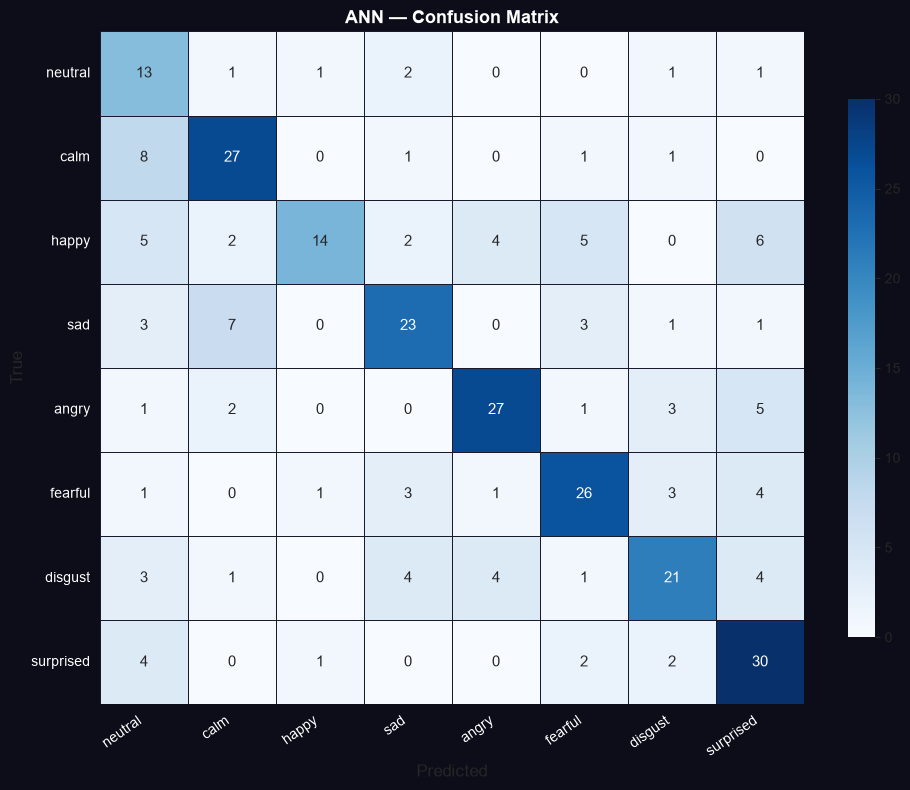

✅ Confusion matrix saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cm_ann.png


In [8]:
def evaluate_dl(name, model, X_te, y_te, emotions, report_dir):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred,        average='weighted', zero_division=0)
    cm   = confusion_matrix(y_te, y_pred)
    cr   = classification_report(y_te, y_pred, target_names=emotions, zero_division=0)

    print(f'\n{"─"*55}')
    print(f'  📊  {name}  —  Test Results')
    print(f'{"─"*55}')
    print(f'  Accuracy   : {acc*100:.2f}%')
    print(f'  Precision  : {prec*100:.2f}%')
    print(f'  Recall     : {rec*100:.2f}%')
    print(f'  F1-Score   : {f1*100:.2f}%')
    print()
    print(cr)

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(10, 8))
    fig.patch.set_facecolor(DARK); ax.set_facecolor(PANEL)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=emotions, yticklabels=emotions,
                ax=ax, linewidths=0.5, linecolor='#1a1a2e',
                annot_kws={'size': 11}, cbar_kws={'shrink': 0.8})
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True',      fontsize=12)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13,
                 color='white', fontweight='bold')
    ax.tick_params(colors='white')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', color='white')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  color='white')
    plt.tight_layout()
    cm_path = os.path.join(report_dir, f'cm_{name.lower().replace(" ","_")}.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight', facecolor=DARK)
    plt.show()
    print(f'✅ Confusion matrix saved → {cm_path}')

    return {'model': name, 'type': 'DL', 'accuracy': acc,
            'precision': prec, 'recall': rec, 'f1': f1,
            'y_pred': y_pred, 'cm': cm}


ann_result = evaluate_dl('ANN', ann_model, X_test_sc, y_test,
                          EMOTIONS, REP_DIR)

## 8.9 — Build CNN Architecture

In [9]:
def build_cnn(input_shape: tuple, n_classes: int) -> keras.Model:
    """
    CNN classifier on 2-D MFCC feature maps.

    Architecture:
      Input(40×130×1)
       → Conv2D(32, 3×3) → BN → ReLU → MaxPool(2×2) → Dropout(0.25)
       → Conv2D(64, 3×3) → BN → ReLU → MaxPool(2×2) → Dropout(0.25)
       → Conv2D(128,3×3) → BN → ReLU → GlobalAvgPool → Dropout(0.30)
       → Dense(256)      → BN → ReLU → Dropout(0.40)
       → Dense(128)      → BN → ReLU → Dropout(0.30)
       → Dense(8)        → Softmax
    """
    inp = keras.Input(shape=input_shape, name='mfcc_2d_input')

    # ── Block 1 ─────────────────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), padding='same', name='conv1',
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization(name='bn_c1')(x)
    x = layers.Activation('relu', name='relu_c1')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.Dropout(0.25, name='drop_c1')(x)

    # ── Block 2 ─────────────────────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding='same', name='conv2',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='bn_c2')(x)
    x = layers.Activation('relu', name='relu_c2')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.Dropout(0.25, name='drop_c2')(x)

    # ── Block 3 ─────────────────────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding='same', name='conv3',
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization(name='bn_c3')(x)
    x = layers.Activation('relu', name='relu_c3')(x)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dropout(0.30, name='drop_c3')(x)

    # ── Dense head ──────────────────────────────────────────────────────
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.40, name='drop_fc1')(x)

    x = layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.30, name='drop_fc2')(x)

    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    return keras.Model(inp, out, name='SER_CNN')


cnn_model = build_cnn((N_MFCC, MAX_FRAMES, 1), N_CLASSES)
cnn_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
cnn_model.summary()
print(f'\n✅ CNN built  |  Total parameters: {cnn_model.count_params():,}')

Model: "SER_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_2d_input (InputLayer)      │ (None, 40, 130, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 40, 130, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c1 (BatchNormalization)      │ (None, 40, 130, 32)    │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c1 (Activation)            │ (None, 40, 130, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 20, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c1 (Dropout)               │ (None, 20, 65, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 20, 65, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c2 (BatchNormalization)      │ (None, 20, 65, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c2 (Activation)            │ (None, 20, 65, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c2 (Dropout)               │ (None, 10, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 10, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_c3 (BatchNormalization)      │ (None, 10, 32, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_c3 (Activation)            │ (None, 10, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_c3 (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc1 (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc2 (BatchNormalization)     │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_fc2 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         1,03

 Total params: 162,056 (633.03 KB)

 Trainable params: 160,840 (628.28 KB)

 Non-trainable params: 1,216 (4.75 KB)


✅ CNN built  |  Total parameters: 162,056


## 8.10 — Train CNN

In [10]:
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

cnn_ckpt = os.path.join(MODEL_DIR, 'cnn_best.keras')
cnn_callbacks = [
    callbacks.ModelCheckpoint(
        cnn_ckpt, monitor='val_accuracy', save_best_only=True,
        verbose=1, mode='max'
    ),
    callbacks.EarlyStopping(
        monitor='val_loss', patience=20, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8,
        min_lr=1e-6, verbose=1
    ),
]

print('🚀 Training CNN on 2-D MFCC maps...')
t0 = time.time()
cnn_history = cnn_model.fit(
    X_cnn_train, y_cnn_train_oh,
    validation_data = (X_cnn_val, y_cnn_val_oh),
    epochs          = 150,
    batch_size      = 32,
    callbacks       = cnn_callbacks,
    verbose         = 1
)
cnn_train_time = time.time() - t0
print(f'\n✅ CNN training complete in {cnn_train_time:.1f}s')

🚀 Training CNN on 2-D MFCC maps...
Epoch 1/150


 1/32 ━━━━━━━━━━━━━━━━━━━━ 2:22 5s/step - accuracy: 0.1875 - loss: 2.5727

 2/32 ━━━━━━━━━━━━━━━━━━━━ 5s 182ms/step - accuracy: 0.1875 - loss: 2.5402

 3/32 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step - accuracy: 0.1875 - loss: 2.5620

 4/32 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.1953 - loss: 2.5778

...


Epoch 62: val_accuracy did not improve from 0.55556


32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 361ms/step - accuracy: 0.5476 - loss: 1.2556 - val_accuracy: 0.3681 - val_loss: 1.7356 - learning_rate: 1.2500e-04


Epoch 62: early stopping


Restoring model weights from the end of the best epoch: 42.



✅ CNN training complete in 408.4s


## 8.11 — CNN Training Curves & Evaluation

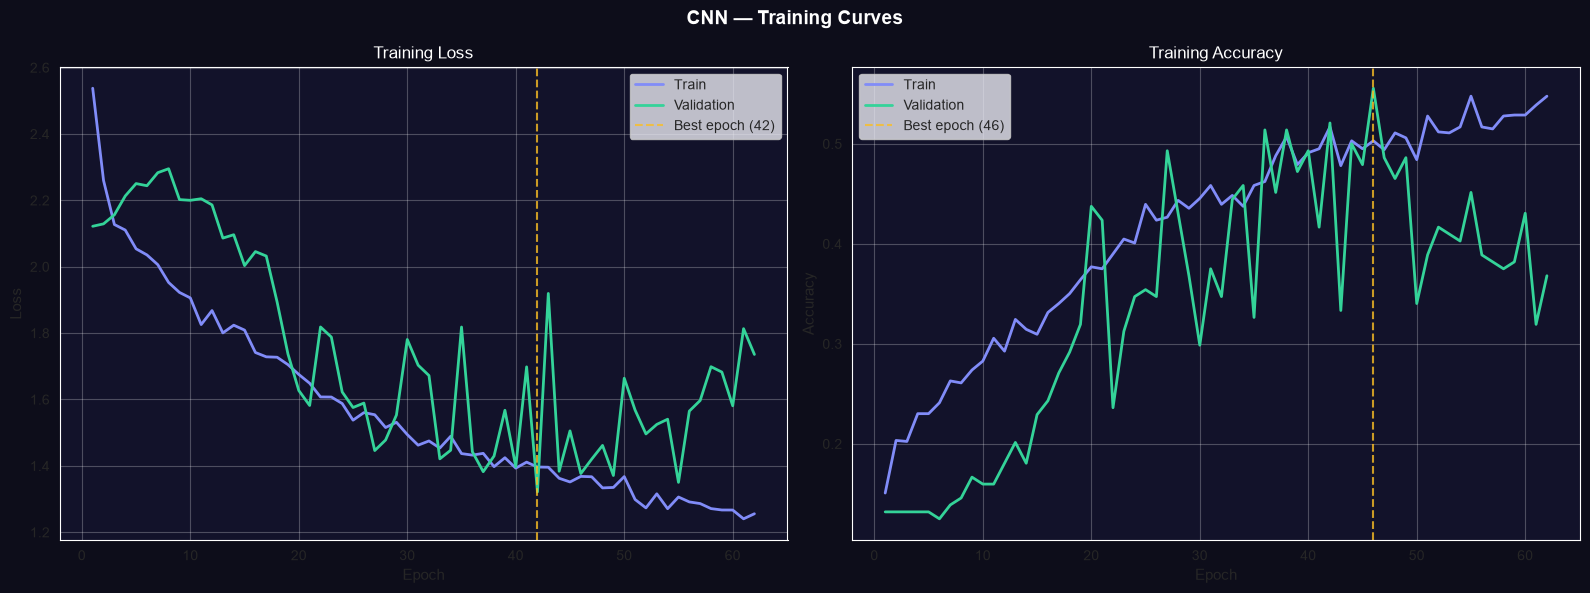

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cnn_training_curves.png



───────────────────────────────────────────────────────
  📊  CNN  —  Test Results
───────────────────────────────────────────────────────
  Accuracy   : 46.88%
  Precision  : 49.37%
  Recall     : 46.88%
  F1-Score   : 44.09%

              precision    recall  f1-score   support

     neutral       0.11      0.11      0.11        19
        calm       0.47      0.95      0.63        38
       happy       0.50      0.08      0.14        38
         sad       0.36      0.24      0.29        38
       angry       0.68      0.49      0.57        39
     fearful       0.34      0.59      0.43        39
     disgust       0.60      0.47      0.53        38
   surprised       0.69      0.64      0.67        39

    accuracy                           0.47       288
   macro avg       0.47      0.45      0.42       288
weighted avg       0.49      0.47      0.44       288



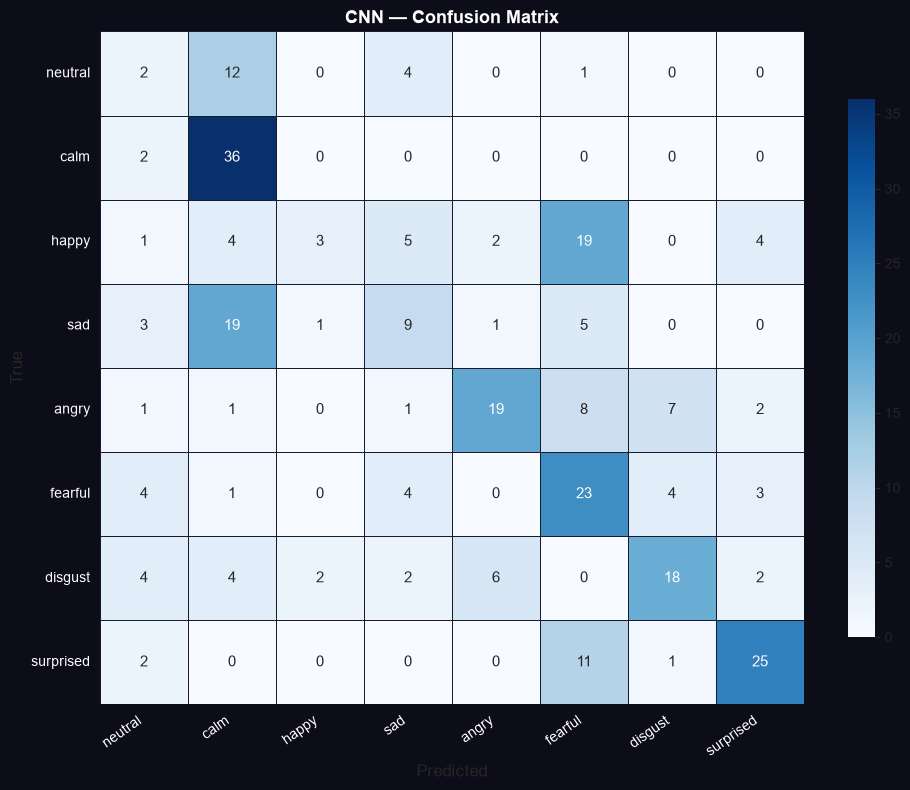

✅ Confusion matrix saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\cm_cnn.png


In [11]:
plot_history(cnn_history, 'CNN — Training Curves',
             os.path.join(REP_DIR, 'cnn_training_curves.png'))

cnn_result = evaluate_dl('CNN', cnn_model, X_cnn_test, y_test,
                          EMOTIONS, REP_DIR)

## 8.12 — ANN vs CNN Training Curves Comparison

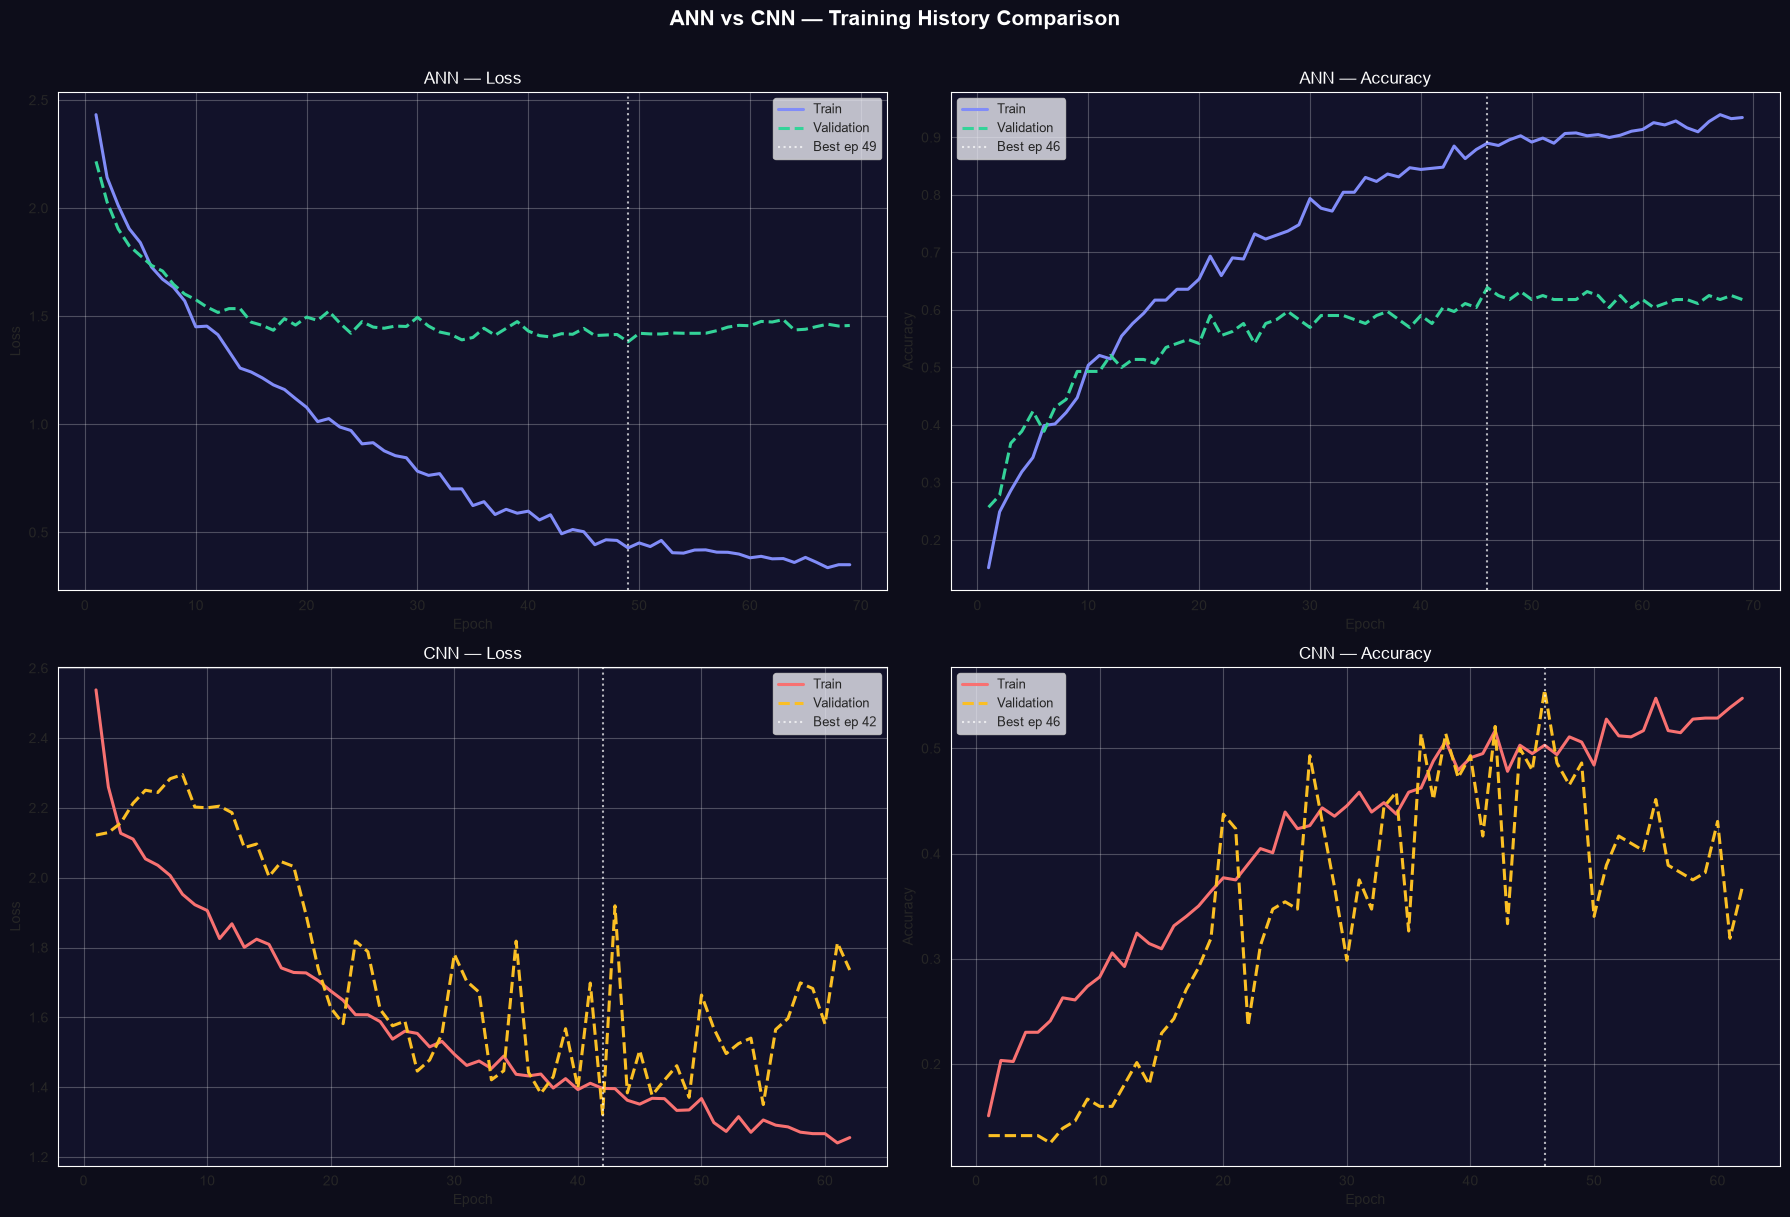

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\ann_vs_cnn_training_comparison.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.patch.set_facecolor(DARK)
fig.suptitle('ANN vs CNN — Training History Comparison',
             fontsize=15, fontweight='bold', color='white', y=1.01)

configs = [
    (ann_history, 'ANN', '#818cf8', '#34d399'),
    (cnn_history, 'CNN', '#f87171', '#fbbf24'),
]

for row, (hist, name, c_train, c_val) in enumerate(configs):
    ep = range(1, len(hist.history['accuracy']) + 1)
    for col, (metric, display) in enumerate([('loss','Loss'),('accuracy','Accuracy')]):
        ax = axes[row][col]
        ax.set_facecolor(PANEL)
        ax.plot(ep, hist.history[metric],          color=c_train,
                linewidth=2.2, label='Train')
        ax.plot(ep, hist.history[f'val_{metric}'], color=c_val,
                linewidth=2.2, label='Validation', linestyle='--')
        best_val = (np.argmin(hist.history['val_loss'])
                    if metric == 'loss'
                    else np.argmax(hist.history['val_accuracy']))
        ax.axvline(best_val+1, color='white', linestyle=':', linewidth=1.5,
                   alpha=0.7, label=f'Best ep {best_val+1}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(display)
        ax.set_title(f'{name} — {display}', color='white', fontsize=12)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)

plt.tight_layout()
path = os.path.join(REP_DIR, 'ann_vs_cnn_training_comparison.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 8.13 — ANN vs CNN Performance Dashboard

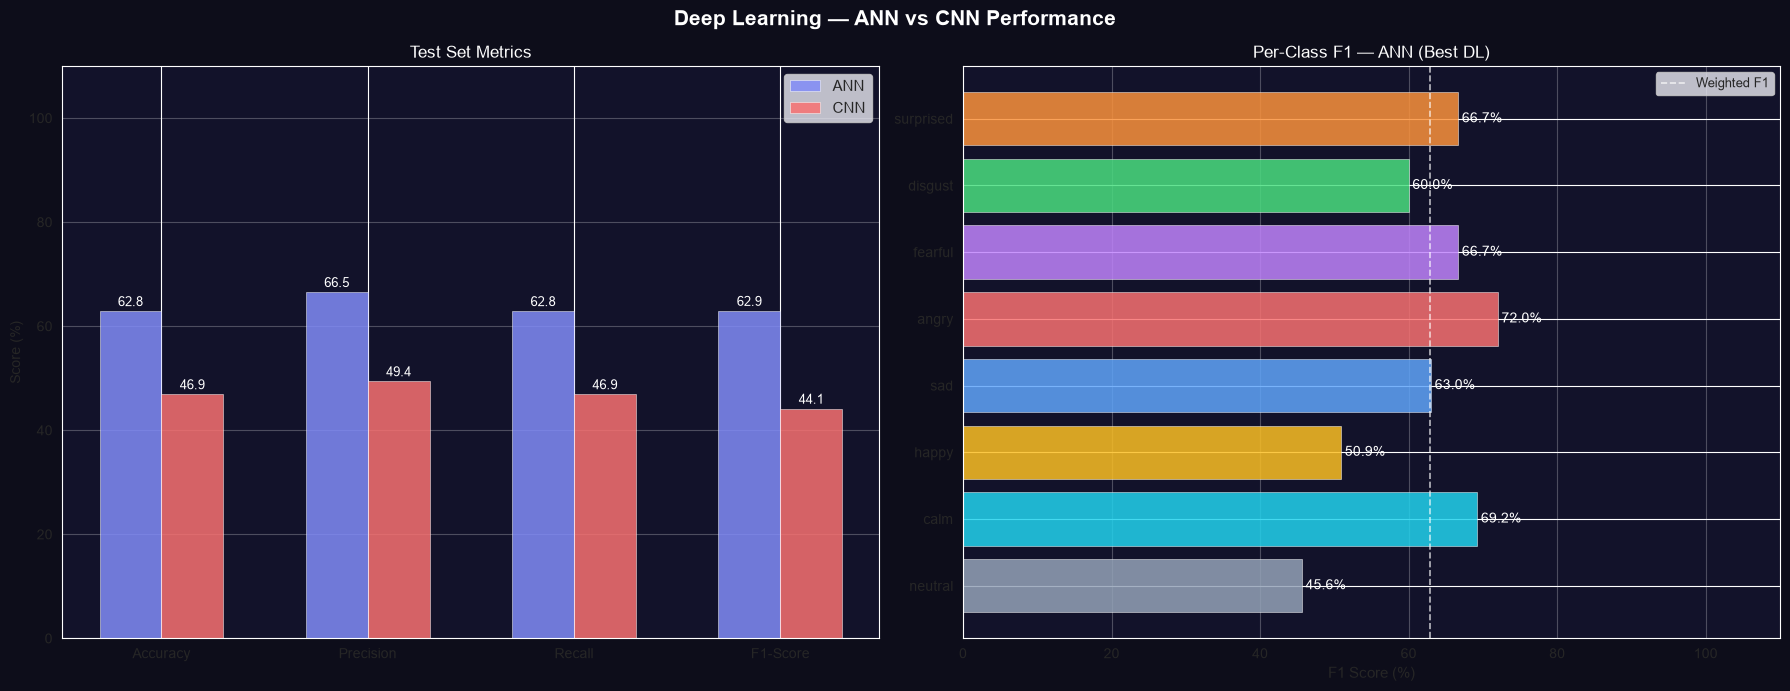

✅ Saved → C:\Speech Emotion Recognition\notebooks\..\reports\evaluation\dl_ann_vs_cnn_dashboard.png


In [13]:
dl_results = {'ANN': ann_result, 'CNN': cnn_result}
dl_names   = ['ANN', 'CNN']
dl_colors  = ['#818cf8', '#f87171']

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor(DARK)
fig.suptitle('Deep Learning — ANN vs CNN Performance',
             fontsize=15, fontweight='bold', color='white')

# ── Metrics bar ────────────────────────────────────────────────────────────
ax = axes[0]
ax.set_facecolor(PANEL)
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(metrics_list))
w = 0.30
for k, (name, col) in enumerate(zip(dl_names, dl_colors)):
    vals = [dl_results[name][m]*100 for m in metrics_list]
    bars = ax.bar(x + (k - 0.5)*w, vals, w, label=name,
                  color=col, alpha=0.85, edgecolor='white', linewidth=0.4)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{v:.1f}', ha='center', va='bottom', fontsize=9, color='white')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy','Precision','Recall','F1-Score'])
ax.set_ylabel('Score (%)')
ax.set_ylim([0, 110])
ax.set_title('Test Set Metrics', color='white', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.25)

# ── Per-class F1 for best DL model ────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor(PANEL)
best_dl = max(dl_results, key=lambda n: dl_results[n]['f1'])
y_pred_best = dl_results[best_dl]['y_pred']
f1_per = f1_score(y_test, y_pred_best, average=None,
                   labels=range(N_CLASSES), zero_division=0)
clrs = [ECOLORS[e] for e in EMOTIONS]
bars = ax2.barh(EMOTIONS, f1_per * 100, color=clrs,
                alpha=0.85, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars, f1_per*100):
    ax2.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=10, color='white')
ax2.set_xlim([0, 110])
ax2.set_xlabel('F1 Score (%)', fontsize=11)
ax2.set_title(f'Per-Class F1 — {best_dl} (Best DL)',
              color='white', fontsize=12)
ax2.grid(axis='x', alpha=0.25)
ax2.axvline(dl_results[best_dl]['f1']*100, color='white',
            linestyle='--', linewidth=1.2, alpha=0.7, label='Weighted F1')
ax2.legend(fontsize=9)

plt.tight_layout()
path = os.path.join(REP_DIR, 'dl_ann_vs_cnn_dashboard.png')
plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print(f'✅ Saved → {path}')

## 8.14 — Save DL Metrics & Module 8 Summary

In [14]:
# Save full Keras models
ann_model.save(os.path.join(MODEL_DIR, 'ann_model.keras'))
cnn_model.save(os.path.join(MODEL_DIR, 'cnn_model.keras'))

# Save metrics CSV (append to ML metrics for module 9)
ml_metrics  = pd.read_csv(os.path.join(REP_DIR, 'ml_metrics.csv'))
dl_rows = []
for name, hist, tr_time in [('ANN', ann_history, ann_train_time),
                              ('CNN', cnn_history, cnn_train_time)]:
    r = dl_results[name]
    best_val_acc = max(hist.history['val_accuracy'])
    dl_rows.append({
        'model'      : name,
        'type'       : 'DL',
        'accuracy'   : round(r['accuracy'],  4),
        'precision'  : round(r['precision'], 4),
        'recall'     : round(r['recall'],    4),
        'f1'         : round(r['f1'],        4),
        'cv_mean'    : round(best_val_acc,   4),  # val accuracy as proxy
        'cv_std'     : 0.0,
    })
dl_df = pd.DataFrame(dl_rows)
all_metrics = pd.concat([ml_metrics, dl_df], ignore_index=True)
all_metrics.to_csv(os.path.join(REP_DIR, 'all_model_metrics.csv'), index=False)
dl_df.to_csv(os.path.join(REP_DIR, 'dl_metrics.csv'), index=False)

print('=' * 62)
print('   MODULE 8 — DEEP LEARNING RESULTS SUMMARY')
print('=' * 62)
print(all_metrics.to_string(index=False))
print('=' * 62)
best_all = all_metrics.loc[all_metrics['f1'].idxmax()]
print(f'\n🏆 BEST MODEL OVERALL: {best_all["model"]}  '
      f'F1={best_all["f1"]*100:.2f}%  Acc={best_all["accuracy"]*100:.2f}%')
print('\n📁 Saved Model Files:')
for f in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(os.path.join(MODEL_DIR, f)) // 1024
    print(f'   {f:<35}  {sz:>6} KB')
print('\n✅ Module 8 Complete — Deep Learning Models Ready!')

   MODULE 8 — DEEP LEARNING RESULTS SUMMARY
              model type  accuracy  precision  recall     f1  cv_mean  cv_std
Logistic Regression   ML    0.5278     0.5336  0.5278 0.5286   0.5618  0.0203
      Random Forest   ML    0.5278     0.5234  0.5278 0.5230   0.5590  0.0212
                SVM   ML    0.6042     0.6210  0.6042 0.6088   0.6396  0.0305
                ANN   DL    0.6285     0.6651  0.6285 0.6290   0.6389  0.0000
                CNN   DL    0.4688     0.4937  0.4688 0.4409   0.5556  0.0000

🏆 BEST MODEL OVERALL: ANN  F1=62.90%  Acc=62.85%

📁 Saved Model Files:
   ann_best.keras                         3727 KB
   ann_model.keras                        3727 KB
   cnn_best.keras                         1994 KB
   cnn_model.keras                        1994 KB
   label_encoder.pkl                         0 KB
   logistic_regression.pkl                   9 KB
   random_forest.pkl                     22238 KB
   scaler.pkl                                6 KB
   svm_model.pkl